# 02. Modelagem Supervisionada com RandomForest no Dataset BETH

Este notebook implementa um fluxo de trabalho completo para detecção de anomalias no dataset BETH usando uma abordagem supervisionada. O processo inclui:

1. Carregamento e divisão estratégica dos dados
2. Engenharia de features temporais
3. Pipeline de pré-processamento robusto
4. Busca manual de hiperparâmetros com validação cruzada
5. Aplicação de Sampler dentro de cada fold para evitar vazamento
6. Treino do modelo final
7. Otimização do limiar de decisão
8. Avaliação final no conjunto de teste

A estratégia utiliza RandomForestClassifier com uma busca manual em grade e validação cruzada estratificada, otimizada para eficiência de memória e robustez metodológica.

In [1]:
# Importações e Configurações
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, 
    ConfusionMatrixDisplay, roc_auc_score, precision_recall_curve, auc
)

# Imbalanced-learn imports
from imblearn.over_sampling import RandomOverSampler

# Configurações globais
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
np.random.seed(42)

print("✅ Todas as bibliotecas importadas com sucesso!")

✅ Todas as bibliotecas importadas com sucesso!


In [2]:
# Carregamento e Divisão Estratégica dos Dados

# Definindo o caminho relativo para a pasta de dados
data_path = "../../../data/raw/BETH"

print("📂 Carregando dados...")

# IMPORTANTE: Este arquivo é o único a ser usado para a abordagem supervisionada,
# pois os arquivos de treino e validação originais contêm apenas uma classe (dados benignos).
# O arquivo de teste contém tanto dados maliciosos quanto benignos, permitindo supervisão.
df = pd.read_csv(os.path.join(data_path, "labelled_testing_data.csv"))

print(f"📊 Dados carregados: {df.shape[0]} linhas, {df.shape[1]} colunas")
print(f"\n📋 Primeiras linhas do dataset:")
print(df.head())

# Criando a coluna alvo 'out' a partir da coluna 'evil'
df['out'] = df['evil']

# Removendo colunas que podem causar vazamento de dados
columns_to_drop = ['sus', 'evil', 'eventId']
df = df.drop(columns=columns_to_drop)

print(f"\n🎯 Distribuição da variável alvo 'out':")
print(df['out'].value_counts())
print(f"\n📈 Proporção de anomalias: {df['out'].mean():.4f} ({df['out'].sum()} de {len(df)})")

# Separando features e target
X = df.drop('out', axis=1)
y = df['out']

# Divisão estratificada em treino (80%) e teste (20%)
# CRUCIAL: usar stratify para manter a proporção extremamente baixa de anomalias
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\n✅ Divisão dos dados concluída:")
print(f"  📚 Treino: {X_train.shape[0]} amostras")
print(f"  🧪 Teste: {X_test.shape[0]} amostras")
print(f"\n🎯 Distribuição no conjunto de treino:")
print(y_train.value_counts())
print(f"  Proporção de anomalias: {y_train.mean():.4f}")
print(f"\n🎯 Distribuição no conjunto de teste:")
print(y_test.value_counts())
print(f"  Proporção de anomalias: {y_test.mean():.4f}")

📂 Carregando dados...
📊 Dados carregados: 188967 linhas, 16 colunas

📋 Primeiras linhas do dataset:
    timestamp  processId  threadId  parentProcessId  userId  mountNamespace  \
0  129.050634        382       382                1     101      4026532232   
1  129.051238        379       379                1     100      4026532231   
2  129.051434          1         1                0       0      4026531840   
3  129.051481          1         1                0       0      4026531840   
4  129.051522          1         1                0       0      4026531840   

       processName         hostName  eventId           eventName  \
0  systemd-resolve  ip-10-100-1-217       41              socket   
1  systemd-network  ip-10-100-1-217       41              socket   
2          systemd  ip-10-100-1-217     1005  security_file_open   
3          systemd  ip-10-100-1-217      257              openat   
4          systemd  ip-10-100-1-217        5               fstat   

                

In [3]:
# Engenharia de Features e Pipeline de Pré-processamento

def create_time_features(df):
    """
    Cria features temporais a partir do timestamp.
    Ordena por hostName e timestamp, depois calcula a diferença temporal.
    """
    df_copy = df.copy()
    
    # Ordenar por hostName e timestamp
    df_copy = df_copy.sort_values(['hostName', 'timestamp'])
    
    # Calcular diferença temporal para o evento anterior, agrupando por hostName
    df_copy['time_diff'] = df_copy.groupby('hostName')['timestamp'].diff()
    
    # Preencher valores nulos iniciais com 0
    df_copy['time_diff'] = df_copy['time_diff'].fillna(0)
    
    return df_copy

print("⏰ Criando features temporais...")

# Aplicar engenharia de features nos conjuntos de treino e teste
X_train = create_time_features(X_train)
X_test = create_time_features(X_test)

print(f"✅ Feature 'time_diff' criada com sucesso!")
print(f"  📊 Estatísticas da time_diff no treino:")
print(X_train['time_diff'].describe())

# Organizando as colunas por tipo
numeric_features = [
    'timestamp', 'processId', 'threadId', 'parentProcessId', 
    'userId', 'argsNum', 'returnValue', 'time_diff'
]

categorical_features = [
    'processName', 'hostName', 'eventName'
]

# Colunas a serem descartadas (alta cardinalidade ou complexidade)
drop_features = [
    'mountNamespace', 'stackAddresses', 'args'
]

print(f"\n📋 Organização das features:")
print(f"  🔢 Numéricas ({len(numeric_features)}): {numeric_features}")
print(f"  📝 Categóricas ({len(categorical_features)}): {categorical_features}")
print(f"  🗑️ Descartadas ({len(drop_features)}): {drop_features}")

# Criando o pré-processador com ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore', 
            max_categories=25,
            sparse_output=False
        ), categorical_features),
        ('drop', 'drop', drop_features)
    ]
)

print(f"\n🔧 Ajustando pré-processador no conjunto de treino...")

# Fit e transform no treino
X_train_proc = preprocessor.fit_transform(X_train)

# Transform no teste
X_test_proc = preprocessor.transform(X_test)

print(f"✅ Pré-processamento concluído!")
print(f"  📊 Shape do treino processado: {X_train_proc.shape}")
print(f"  📊 Shape do teste processado: {X_test_proc.shape}")
print(f"  🎯 Features criadas após encoding: {X_train_proc.shape[1]}")

⏰ Criando features temporais...
✅ Feature 'time_diff' criada com sucesso!
  📊 Estatísticas da time_diff no treino:
count    151173.000000
mean          0.002432
std           0.189695
min           0.000000
25%           0.000022
50%           0.000023
75%           0.000044
max          31.125996
Name: time_diff, dtype: float64

📋 Organização das features:
  🔢 Numéricas (8): ['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId', 'argsNum', 'returnValue', 'time_diff']
  📝 Categóricas (3): ['processName', 'hostName', 'eventName']
  🗑️ Descartadas (3): ['mountNamespace', 'stackAddresses', 'args']

🔧 Ajustando pré-processador no conjunto de treino...
✅ Pré-processamento concluído!
  📊 Shape do treino processado: (151173, 59)
  📊 Shape do teste processado: (37794, 59)
  🎯 Features criadas após encoding: 59


## Estratégia de Busca Manual com Validação Cruzada

Implementaremos uma busca manual em grade com um loop de validação cruzada interna. Esta abordagem oferece várias vantagens:

- **Eficiência de memória**: Mais eficiente que GridSearchCV para datasets grandes
- **Controle de vazamento**: Sampler aplicado dentro de cada fold, evitando vazamento de dados
- **Flexibilidade**: Permite customizações específicas no processo de avaliação
- **Transparência**: Controle total sobre cada etapa do processo

O Sampler será aplicado apenas na porção de treino de cada fold, garantindo que os dados de validação permaneçam "não vistos" e não balanceados, simulando melhor o cenário real de produção.

In [4]:
# Busca Manual de Hiperparâmetros com Validação Cruzada (CV)

# Definindo a grade de parâmetros para o RandomForestClassifier
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

print(f"🔍 Iniciando busca manual de hiperparâmetros...")
print(f"📊 Grade de parâmetros:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

# Calculando o número total de combinações
total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n🎯 Total de combinações: {total_combinations}")

# Configuração da validação cruzada
cv_folds = 3
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

print(f"📋 Configuração da validação cruzada: {cv_folds} folds")

# Lista para armazenar os resultados
results = []

# Loop externo: iteração sobre combinações de hiperparâmetros
combination_count = 0
for n_est in tqdm(param_grid['n_estimators'], desc="n_estimators"):
    for max_d in param_grid['max_depth']:
        for min_leaf in param_grid['min_samples_leaf']:
            for class_w in param_grid['class_weight']:
                combination_count += 1
                
                print(f"\n🔄 Combinação {combination_count}/{total_combinations}:")
                print(f"  n_estimators={n_est}, max_depth={max_d}, min_samples_leaf={min_leaf}, class_weight={class_w}")
                
                # Lista para armazenar F1-scores dos folds
                fold_f1_scores = []
                
                # Loop interno: validação cruzada
                for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_proc, y_train)):
                    # Dividir dados do fold
                    X_fold_train = X_train_proc[train_idx]
                    y_fold_train = y_train.iloc[train_idx]
                    X_fold_val = X_train_proc[val_idx]
                    y_fold_val = y_train.iloc[val_idx]
                    
                    # Verificar se há pelo menos duas classes no treino do fold
                    if len(y_fold_train.unique()) < 2:
                        print(f"    ⚠️  Fold {fold_idx+1}: Apenas uma classe no treino. Pulando...")
                        continue
                    
                    # Aplicar sampler apenas no treino do fold
                    try:
                        sampler = RandomOverSampler(random_state=42)
                        X_fold_train_balanced, y_fold_train_balanced = sampler.fit_resample(
                            X_fold_train, y_fold_train
                        )
                    except Exception as e:
                        print(f"    ⚠️  Fold {fold_idx+1}: Erro no Sampler: {e}. Usando dados originais...")
                        X_fold_train_balanced = X_fold_train
                        y_fold_train_balanced = y_fold_train
                    
                    # Treinar RandomForestClassifier
                    rf = BalancedRandomForestClassifier(
                        n_estimators=n_est,
                        max_depth=max_d,
                        min_samples_leaf=min_leaf,
                        class_weight=class_w,
                        random_state=42,
                        n_jobs=-1
                    )
                    
                    rf.fit(X_fold_train_balanced, y_fold_train_balanced)
                    
                    # Predizer na validação (dados não balanceados)
                    y_fold_pred = rf.predict(X_fold_val)
                    
                    # Calcular F1-score da classe positiva (maliciosa)
                    fold_f1 = f1_score(y_fold_val, y_fold_pred, average='macro', zero_division="warn")
                    fold_f1_scores.append(fold_f1)
                    
                    print(f"    ✅ Fold {fold_idx+1}: F1-score = {fold_f1:.4f}")
                
                # Calcular média dos F1-scores válidos
                if fold_f1_scores:
                    mean_f1 = np.mean(fold_f1_scores)
                    std_f1 = np.std(fold_f1_scores)
                    print(f"  📊 Média F1: {mean_f1:.4f} ± {std_f1:.4f} ({len(fold_f1_scores)} folds válidos)")
                    
                    # Armazenar resultado
                    results.append({
                        'n_estimators': n_est,
                        'max_depth': max_d,
                        'min_samples_leaf': min_leaf,
                        'class_weight': class_w,
                        'mean_f1': mean_f1,
                        'std_f1': std_f1,
                        'valid_folds': len(fold_f1_scores)
                    })
                else:
                    print(f"  ❌ Nenhum fold válido para esta combinação")

print(f"\n✅ Busca de hiperparâmetros concluída!")
print(f"📊 {len(results)} combinações avaliadas com sucesso")

🔍 Iniciando busca manual de hiperparâmetros...
📊 Grade de parâmetros:
  n_estimators: [100, 200]
  max_depth: [10, 20, None]
  min_samples_leaf: [1, 2, 4]
  class_weight: ['balanced', 'balanced_subsample', None]

🎯 Total de combinações: 54
📋 Configuração da validação cruzada: 3 folds


n_estimators:   0%|                                                                              | 0/2 [00:00<?, ?it/s]


🔄 Combinação 1/54:
  n_estimators=100, max_depth=10, min_samples_leaf=1, class_weight=balanced
    ✅ Fold 1: F1-score = 0.3302
    ✅ Fold 2: F1-score = 0.4260
    ✅ Fold 3: F1-score = 0.3056
  📊 Média F1: 0.3539 ± 0.0519 (3 folds válidos)

🔄 Combinação 2/54:
  n_estimators=100, max_depth=10, min_samples_leaf=1, class_weight=balanced_subsample
    ✅ Fold 1: F1-score = 0.3302
    ✅ Fold 2: F1-score = 0.4260
    ✅ Fold 3: F1-score = 0.3056
  📊 Média F1: 0.3539 ± 0.0519 (3 folds válidos)

🔄 Combinação 3/54:
  n_estimators=100, max_depth=10, min_samples_leaf=1, class_weight=None
    ✅ Fold 1: F1-score = 0.3302
    ✅ Fold 2: F1-score = 0.4260
    ✅ Fold 3: F1-score = 0.3056
  📊 Média F1: 0.3539 ± 0.0519 (3 folds válidos)

🔄 Combinação 4/54:
  n_estimators=100, max_depth=10, min_samples_leaf=2, class_weight=balanced
    ✅ Fold 1: F1-score = 0.2844
    ✅ Fold 2: F1-score = 0.3838
    ✅ Fold 3: F1-score = 0.3398
  📊 Média F1: 0.3360 ± 0.0406 (3 folds válidos)

🔄 Combinação 5/54:
  n_estimators

n_estimators:  50%|██████████████████████████████████▌                                  | 1/2 [12:12<12:12, 732.18s/it]

    ✅ Fold 3: F1-score = 0.4986
  📊 Média F1: 0.5004 ± 0.0013 (3 folds válidos)

🔄 Combinação 28/54:
  n_estimators=200, max_depth=10, min_samples_leaf=1, class_weight=balanced
    ✅ Fold 1: F1-score = 0.3314
    ✅ Fold 2: F1-score = 0.4062
    ✅ Fold 3: F1-score = 0.3016
  📊 Média F1: 0.3464 ± 0.0440 (3 folds válidos)

🔄 Combinação 29/54:
  n_estimators=200, max_depth=10, min_samples_leaf=1, class_weight=balanced_subsample
    ✅ Fold 1: F1-score = 0.3314
    ✅ Fold 2: F1-score = 0.4062
    ✅ Fold 3: F1-score = 0.3016
  📊 Média F1: 0.3464 ± 0.0440 (3 folds válidos)

🔄 Combinação 30/54:
  n_estimators=200, max_depth=10, min_samples_leaf=1, class_weight=None
    ✅ Fold 1: F1-score = 0.3314
    ✅ Fold 2: F1-score = 0.4062
    ✅ Fold 3: F1-score = 0.3016
  📊 Média F1: 0.3464 ± 0.0440 (3 folds válidos)

🔄 Combinação 31/54:
  n_estimators=200, max_depth=10, min_samples_leaf=2, class_weight=balanced
    ✅ Fold 1: F1-score = 0.2810
    ✅ Fold 2: F1-score = 0.3861
    ✅ Fold 3: F1-score = 0.294

n_estimators: 100%|████████████████████████████████████████████████████████████████████| 2/2 [36:42<00:00, 1101.32s/it]

    ✅ Fold 3: F1-score = 0.4974
  📊 Média F1: 0.4996 ± 0.0016 (3 folds válidos)

✅ Busca de hiperparâmetros concluída!
📊 54 combinações avaliadas com sucesso


In [5]:
# Análise dos Resultados do Tuning e Treino do Modelo Final

# Converter resultados em DataFrame
results_df = pd.DataFrame(results)

if len(results_df) == 0:
    print("❌ Nenhum resultado válido encontrado!")
else:
    print(f"📊 Resultados da busca de hiperparâmetros:")
    print(results_df.sort_values('mean_f1', ascending=False).head(10))
    
    # Encontrar a melhor combinação
    best_idx = results_df['mean_f1'].idxmax()
    best_params = results_df.loc[best_idx]
    
    print(f"\n🏆 Melhor combinação encontrada:")
    print(f"  n_estimators: {best_params['n_estimators']}")
    print(f"  max_depth: {best_params['max_depth']}")
    print(f"  min_samples_leaf: {best_params['min_samples_leaf']}")
    print(f"  class_weight: {best_params['class_weight']}")
    print(f"  F1-score médio: {best_params['mean_f1']:.4f} ± {best_params['std_f1']:.4f}")
    
    # Tratar o caso em que max_depth é None (convertido para NaN no DataFrame)
    best_max_depth = int(best_params['max_depth']) if pd.notna(best_params['max_depth']) else None
    
    print(f"\n🔧 Treinando modelo final com os melhores hiperparâmetros...")
    
    # Aplicar Sampler no conjunto de treino completo
    try:
        sampler_final = RandomOverSampler(random_state=42)
        X_train_final_balanced, y_train_final_balanced = sampler_final.fit_resample(
            X_train_proc, y_train
        )
        print(f"✅ Sampler aplicado no conjunto completo")
        print(f"  📊 Shape antes do Sampler: {X_train_proc.shape}")
        print(f"  📊 Shape após Sampler: {X_train_final_balanced.shape}")
        print(f"  🎯 Distribuição após Sampler:")
        print(pd.Series(y_train_final_balanced).value_counts())
    except Exception as e:
        print(f"⚠️  Erro no Sampler final: {e}. Usando dados originais...")
        X_train_final_balanced = X_train_proc
        y_train_final_balanced = y_train
    
    # Treinar o modelo final
    final_model = BalancedRandomForestClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=best_max_depth,
        min_samples_leaf=int(best_params['min_samples_leaf']),
        class_weight=best_params['class_weight'],
        random_state=42,
        n_jobs=-1
    )
    
    final_model.fit(X_train_final_balanced, y_train_final_balanced)
    
    print(f"✅ Modelo final treinado com sucesso!")
    print(f"🌳 Número de árvores: {final_model.n_estimators}")
    print(f"📏 Profundidade máxima: {final_model.max_depth}")

📊 Resultados da busca de hiperparâmetros:
    n_estimators  max_depth  min_samples_leaf        class_weight   mean_f1  \
49           200        NaN                 2  balanced_subsample  0.502166   
50           200        NaN                 2                None  0.502166   
48           200        NaN                 2            balanced  0.502166   
22           100        NaN                 2  balanced_subsample  0.501923   
21           100        NaN                 2            balanced  0.501923   
23           100        NaN                 2                None  0.501923   
47           200        NaN                 1                None  0.501529   
46           200        NaN                 1  balanced_subsample  0.501529   
45           200        NaN                 1            balanced  0.501529   
19           100        NaN                 1  balanced_subsample  0.501260   

      std_f1  valid_folds  
49  0.003163            3  
50  0.003163            3  
48  

🎯 Iniciando avaliação final no conjunto de teste...
✅ Probabilidades preditas no teste
  📊 Estatísticas das probabilidades:
    Mínima: 0.0291
    Máxima: 0.9851
    Média: 0.7131
    Mediana: 0.7897

🎯 Otimização do limiar de decisão:
  🏆 Melhor limiar: 0.0291
  📊 F1-score com limiar otimizado: 0.9121
  📈 Precisão: 0.8384
  📈 Recall: 1.0000

📊 RESULTADOS FINAIS COM LIMIAR OTIMIZADO (0.0291):

📋 Classification Report:
              precision    recall  f1-score   support

     Benigno       0.00      0.00      0.00      6107
   Malicioso       0.84      1.00      0.91     31687

    accuracy                           0.84     37794
   macro avg       0.42      0.50      0.46     37794
weighted avg       0.70      0.84      0.76     37794


🎯 ROC AUC Score: 0.4951
🎯 PR AUC Score: 0.8386

🔍 Matriz de Confusão:
[[    0  6107]
 [    0 31687]]


<Figure size 800x600 with 0 Axes>

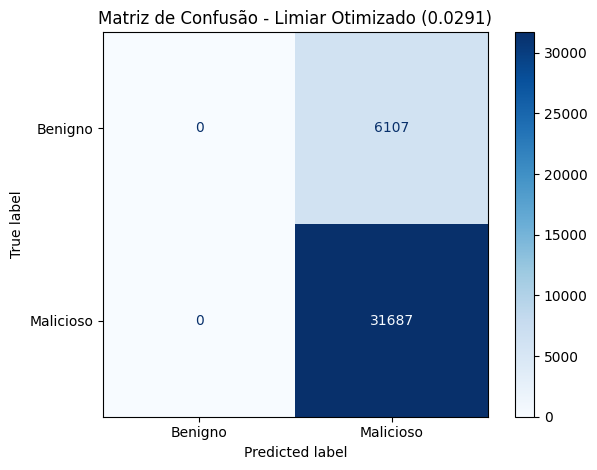


📊 COMPARAÇÃO COM LIMIAR PADRÃO (0.5):
F1-score com limiar 0.5: 0.8403
F1-score com limiar otimizado: 0.9121
Melhoria: 8.54%

📈 Distribuição das previsões:
  Limiar 0.5 - Predições positivas: 31890 de 37794
  Limiar 0.0291 - Predições positivas: 37794 de 37794
  Valores reais positivos: 31687 de 37794


In [6]:
# Avaliação Final e Otimização do Limiar de Decisão

if len(results_df) == 0:
    print("❌ Não é possível fazer avaliação - nenhum modelo treinado!")
else:
    print(f"🎯 Iniciando avaliação final no conjunto de teste...")
    
    # Predizer probabilidades no conjunto de teste
    y_test_proba = final_model.predict_proba(X_test_proc)[:, 1]  # Probabilidade da classe positiva
    
    print(f"✅ Probabilidades preditas no teste")
    print(f"  📊 Estatísticas das probabilidades:")
    print(f"    Mínima: {y_test_proba.min():.4f}")
    print(f"    Máxima: {y_test_proba.max():.4f}")
    print(f"    Média: {y_test_proba.mean():.4f}")
    print(f"    Mediana: {np.median(y_test_proba):.4f}")
    
    # Otimização do limiar usando a curva Precision-Recall
    precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)
    
    # Calcular F1-score para cada limiar
    f1_scores = 2 * (precision * recall) / (precision + recall)
    f1_scores = np.nan_to_num(f1_scores)  # Tratar divisões por zero
    
    # Encontrar o limiar que maximiza o F1-score
    best_threshold_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_threshold_idx]
    best_f1 = f1_scores[best_threshold_idx]
    
    print(f"\n🎯 Otimização do limiar de decisão:")
    print(f"  🏆 Melhor limiar: {best_threshold:.4f}")
    print(f"  📊 F1-score com limiar otimizado: {best_f1:.4f}")
    print(f"  📈 Precisão: {precision[best_threshold_idx]:.4f}")
    print(f"  📈 Recall: {recall[best_threshold_idx]:.4f}")
    
    # Aplicar o limiar otimizado
    y_test_pred_optimized = (y_test_proba >= best_threshold).astype(int)
    
    # Também gerar previsões com limiar padrão (0.5) para comparação
    y_test_pred_default = (y_test_proba >= 0.5).astype(int)
    
    print(f"\n📊 RESULTADOS FINAIS COM LIMIAR OTIMIZADO ({best_threshold:.4f}):")
    print("=" * 60)
    
    # Classification Report
    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_test_pred_optimized, target_names=['Benigno', 'Malicioso']))
    
    # ROC AUC Score
    try:
        roc_auc = roc_auc_score(y_test, y_test_proba)
        print(f"\n🎯 ROC AUC Score: {roc_auc:.4f}")
    except Exception as e:
        print(f"⚠️  Não foi possível calcular ROC AUC: {e}")
    
    # PR AUC Score
    try:
        pr_auc = auc(recall, precision)
        print(f"🎯 PR AUC Score: {pr_auc:.4f}")
    except Exception as e:
        print(f"⚠️  Não foi possível calcular PR AUC: {e}")
    
    # Confusion Matrix
    print(f"\n🔍 Matriz de Confusão:")
    cm = confusion_matrix(y_test, y_test_pred_optimized)
    print(cm)
    
    # Visualização da Confusion Matrix
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Malicioso'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Matriz de Confusão - Limiar Otimizado ({best_threshold:.4f})')
    plt.tight_layout()
    plt.show()
    
    # Comparação com limiar padrão
    print(f"\n📊 COMPARAÇÃO COM LIMIAR PADRÃO (0.5):")
    print("=" * 50)
    
    f1_default = f1_score(y_test, y_test_pred_default)
    f1_optimized = f1_score(y_test, y_test_pred_optimized)
    
    print(f"F1-score com limiar 0.5: {f1_default:.4f}")
    print(f"F1-score com limiar otimizado: {f1_optimized:.4f}")
    print(f"Melhoria: {((f1_optimized / f1_default) - 1) * 100:.2f}%" if f1_default > 0 else "N/A")
    
    # Distribuição das previsões
    print(f"\n📈 Distribuição das previsões:")
    print(f"  Limiar 0.5 - Predições positivas: {y_test_pred_default.sum()} de {len(y_test)}")
    print(f"  Limiar {best_threshold:.4f} - Predições positivas: {y_test_pred_optimized.sum()} de {len(y_test)}")
    print(f"  Valores reais positivos: {y_test.sum()} de {len(y_test)}")